In [ ]:
# Direct wrappers
#
# https://tslearn.readthedocs.io/en/latest/gen_modules/tslearn.clustering.html#module-tslearn.clustering
# https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.clustering.k_medoids.TimeSeriesKMedoids.html#sktime.clustering.k_medoids.TimeSeriesKMedoids


import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import random

from timex import lmm_v1, lmm_v2


In [ ]:
AKI_PATH = os.environ['AKI_PATH_NEW']
os.chdir(AKI_PATH)

ts_data = pd.read_parquet("data_preparation_DV_final_for_LCMM_19785AKIpatients_FU7-3650d_SW365d_TR90d_13032025.parquet")
ts_data = ts_data.assign(ID=ts_data.ID.astype('int64'))

In [ ]:
# X = [n_ts, sz, dim]
# if there is no interpolation we assume that the time dimension is the second one
# i.e. we have at least 2 dimensions

ts_data = ts_data.rename(columns={"Time_since_index_AKI_days": "Time_days"})

In [ ]:
ts_data = ts_data[['Time_days', 'eGFR_int', 'ID']]

In [ ]:
test_selection = random.choices(ts_data.ID.unique().tolist(), k=500)

In [ ]:
clusters_8_timexCustom = lmm_v1.time_clustering(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3,
                                    how='normal', 
                                    num_samples=1500,
                                    normalize=True)


In [ ]:
clusters_8_timexCustom2_nonorm = lmm_v2.fit_lmm_and_cluster(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    normalize=False)

In [ ]:
clusters_8_timexCustom2_norm = lmm_v2.fit_lmm_and_cluster(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    normalize=True)

In [ ]:
clusters_8_timexCustom3_nonnorm = lmm_v2.two_stage_growth_mixture(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    num_warmup=500,
                                    normalize=False)

In [ ]:
clusters_8_timexCustom3_norm = lmm_v2.two_stage_growth_mixture(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    num_warmup=500,
                                    normalize=True)

In [ ]:
clusters_8_timexCustom4_nonnorm = lmm_v2.fit_lcmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    num_warmup=500,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    num_chains=8,
                                    normalize=False)

In [ ]:
clusters_8_timexCustom4_norm = lmm_v2.fit_lcmm(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_samples=1500,
                                    num_warmup=500,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    num_chains=8,
                                    normalize=True)

In [ ]:
clusters_8_timexCustom5_norm = lmm_v2.fit_lcmm_vi(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_steps=5000,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    normalize=True)

In [ ]:
clusters_8_timexCustom5_nonnorm = lmm_v2.fit_lcmm_vi(ts_data.loc[ts_data.ID.isin(test_selection)], 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    spline_df=6, 
                                    spline_degree=3, 
                                    num_steps=5000,
                                    discrete=False, # use Gumbel to make the sampling differentiable
                                    normalize=True)

In [ ]:
# for fpca clustering we require interpolation
from timex import preprocessing

In [41]:
df = ts_data.loc[ts_data.ID.isin(test_selection)]
df_interp = preprocessing.get_interpolated(df, id_col='ID', time_col='Time_days', val_col='eGFR_int', keep_t0_value=True, time_res=30, days_before=0, max_days=1860, df_out=True).dropna()

In [56]:
_df = df_interp.groupby('ID').max('Time_days')
index_1 = _df.loc[_df.Time_days==1830].index
_df = df_interp.groupby('ID').min('Time_days')
index_2 = _df.loc[_df.Time_days==30].index
df_interp = df_interp.loc[df_interp.ID.isin(index_1) & df_interp.ID.isin(index_2)]

In [58]:
clusters_8_timexCustom6_norm = lmm_v2.fpca_clustering(df_interp, 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    n_components=7, 
                                    normalize=True)

In [59]:
clusters_8_timexCustom6_nonorm = lmm_v2.fpca_clustering(df_interp, 'Time_days', 'eGFR_int', 'ID', 
                                    n_clusters=8, 
                                    n_components=5, 
                                    normalize=False)

In [71]:
res_list = []
for clnum, idlist in enumerate(clusters_8_timexCustom4_norm):
    for id in idlist:
        res_list.append({
            'clusters_8_timexCustom4_nonnorm': clnum, 
            'ID': id
        })

ts_data = pd.merge(ts_data, pd.DataFrame(res_list), how='left', on='ID')

In [65]:
ts_data = ts_data.fillna(-1)

<Axes: xlabel='Time_days', ylabel='eGFR_int'>

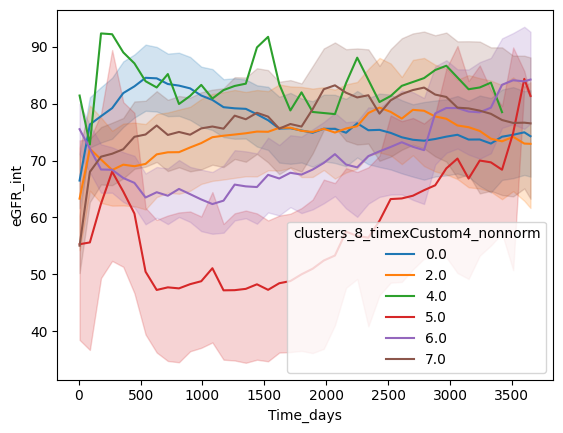

In [72]:
sns.lineplot(ts_data[ts_data.ID.isin(test_selection)], x='Time_days', y='eGFR_int', hue='clusters_8_timexCustom4_nonnorm', palette='tab10')

In [ ]:
num_plots_per_clusters = 100

cmap_ = plt.get_cmap('tab10', len(clusters_8))
cluster_colors = {c: cmap_(c) for c in range(len(clusters_8))}

fig, ax = plt.subplots(figsize=(18, 8))

for ck, cl in enumerate(clusters_8):
    for sid in random.choices(cl, k=num_plots_per_clusters):
        sub = ts_data[ts_data['ID'] == sid]
        ax.plot(sub['Time_days'], sub['eGFR_int'], lw=2, label=ck, color=cluster_colors[ck], alpha=0.1)
ax.set_title('Timeseries by Predicted Cluster')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='small')